In [1]:
from datasets import load_dataset
import pandas as pd
import random

In [2]:
dataset = load_dataset("allenai/sciq", split = "train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.02k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.99M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/339k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11679 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
df = pd.DataFrame(dataset)
print("Original rows:", len(df))

Original rows: 11679


In [4]:
df = df.drop_duplicates(subset=["question"])

In [5]:
len(df)  # 70 duplicate questions dropped.

11609

In [6]:
df = df.dropna(subset=["question","correct_answer","distractor1","distractor2","distractor3"])

In [7]:
import re

In [8]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
for col in ["question","correct_answer","distractor1","distractor2","distractor3"]:
    df[col] = df[col].apply(clean_text)

In [9]:
df = df.sample(n=2000, random_state=42)
print("Final sampled rows:", len(df))

Final sampled rows: 2000


In [10]:
df.head()

,question,distractor3,distractor1,distractor2,correct_answer,support
7325,"When atoms gain or lose electrons, they can fo...",toxins,crystals,eons,ions,"In ordinary chemical reactions, the nucleus of..."
10579,"What control reproductive cycles, which are in...",nerve impulses,brain waves,enzymes,hormones,
4885,Wich disorder arises when defective valves all...,cataracts veins,vascular disease,bulging veins,varicose veins,"Edema may be accompanied by varicose veins, es..."
4235,Because core electrons are closer to the nucle...,fission,diffusion,splitting,bonding,Core electrons are the electrons that are clos...
3554,"""endocrine"" and ""exocrine"" are two types of what?",cells,organs,fluids,glands,The ductless endocrine glands are not to be co...


In [11]:
final_rows = []
for _, row in df.iterrows():
  options = [
      row['correct_answer'],
      row['distractor1'],
      row['distractor2'],
      row['distractor3']
  ]
  random.shuffle(options)
  answer_index = options.index(row["correct_answer"])
  answer_key = "ABCD"[answer_index]
  final_rows.append({
      "dataset_source": "SciQ",
      "text":f"Question: {row['question']}\n\n" f"A. {options[0]}\n" f"B. {options[1]}\n" f"C. {options[2]}\n" f"D. {options[3]}\n\n" f"Answer: {answer_key}",
      "answer_key": answer_key
  })
  clean_df = pd.DataFrame(final_rows)

In [12]:
clean_df.head()

,dataset_source,text,answer_key
0,SciQ,"Question: When atoms gain or lose electrons, t...",A
1,SciQ,"Question: What control reproductive cycles, wh...",D
2,SciQ,Question: Wich disorder arises when defective ...,A
3,SciQ,Question: Because core electrons are closer to...,C
4,SciQ,"Question: ""endocrine"" and ""exocrine"" are two t...",A


In [13]:
clean_df.to_csv("sciq_clean.csv",index=False)

In [14]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   dataset_source  2000 non-null   object
 1   text            2000 non-null   object
 2   answer_key      2000 non-null   object
dtypes: object(3)
memory usage: 47.0+ KB


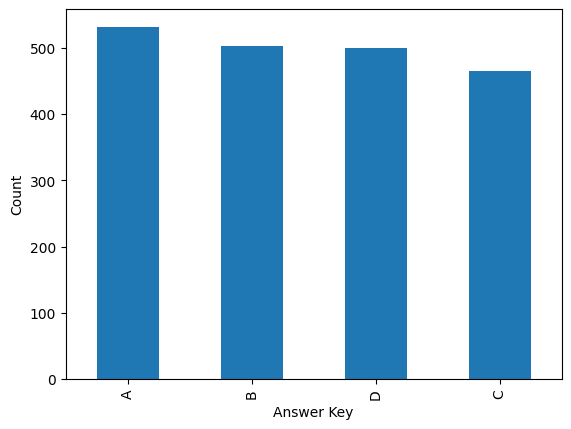

In [15]:
# ans distribution
import matplotlib.pyplot as plt
clean_df['answer_key'].value_counts().plot(kind='bar')
plt.xlabel('Answer Key')
plt.ylabel('Count')
plt.show()

- most of the answers are A, followed by C, B, D
- roughly equal counts for A/B/C/D because of shuffling.

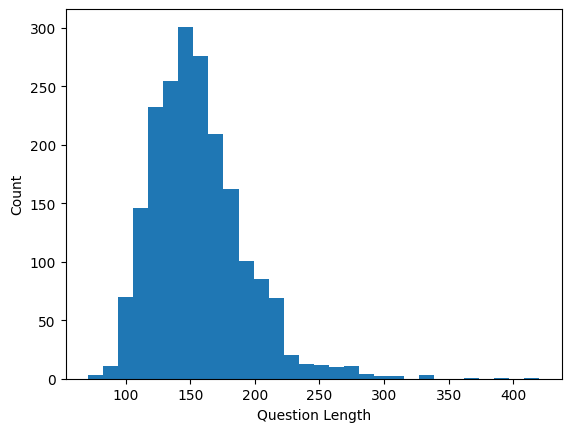

In [16]:
# ques length distribution
ques_len = clean_df['text'].str.len()
plt.hist(ques_len, bins=30)
plt.xlabel('Question Length')
plt.ylabel('Count')
plt.show()

- most of the ques are around 150 characters long.
- very few questions are larger than 350 characters.

In [17]:
ques_len.describe()

,text
count,2000.000000
mean,156.489000
std,36.440291
min,71.000000
25%,131.000000
50%,152.000000
75%,175.000000
max,420.000000


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
import json
path = "/content/drive/MyDrive/Colab Notebooks/SciQ_clean_preprocess"
with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)
nb.get("metadata", {}).pop("widgets", None)
for cell in nb.get("cells", []):
    cell.get("metadata", {}).pop("widgets", None)
with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)
print("Fixed notebook metadata!")

Fixed notebook metadata!
